# Take a CSV file of historical GBP/USD prices and use Python to calculate the daily percentage returns and the average volatility.

In [3]:
import pandas as pd
import numpy as np

# 1. Create a range of dates for 2026
dates = pd.date_range(start="2026-01-01", periods=100, freq='D')

# 2. Generate random "Close" prices starting at 1.25 (typical GBP/USD rate)
np.random.seed(42)
prices = 1.25 + np.cumsum(np.random.normal(0, 0.01, 100))

# 3. Build the Dataframe
df = pd.DataFrame({'Close': prices}, index=dates)

# --- YOUR ACTION START ---

# 4. Calculate Daily Percentage Returns
# Formula: (Today - Yesterday) / Yesterday
df['Returns'] = df['Close'].pct_change()

# 5. Calculate Volatility (Standard Deviation)
# std() is the "spread" of your returns
volatility = df['Returns'].std()

print(f"Average Daily Volatility: {volatility:.4f}")
print(df.head())


Average Daily Volatility: 0.0077
               Close   Returns
2026-01-01  1.254967       NaN
2026-01-02  1.253584 -0.001102
2026-01-03  1.260061  0.005167
2026-01-04  1.275292  0.012087
2026-01-05  1.272950 -0.001836


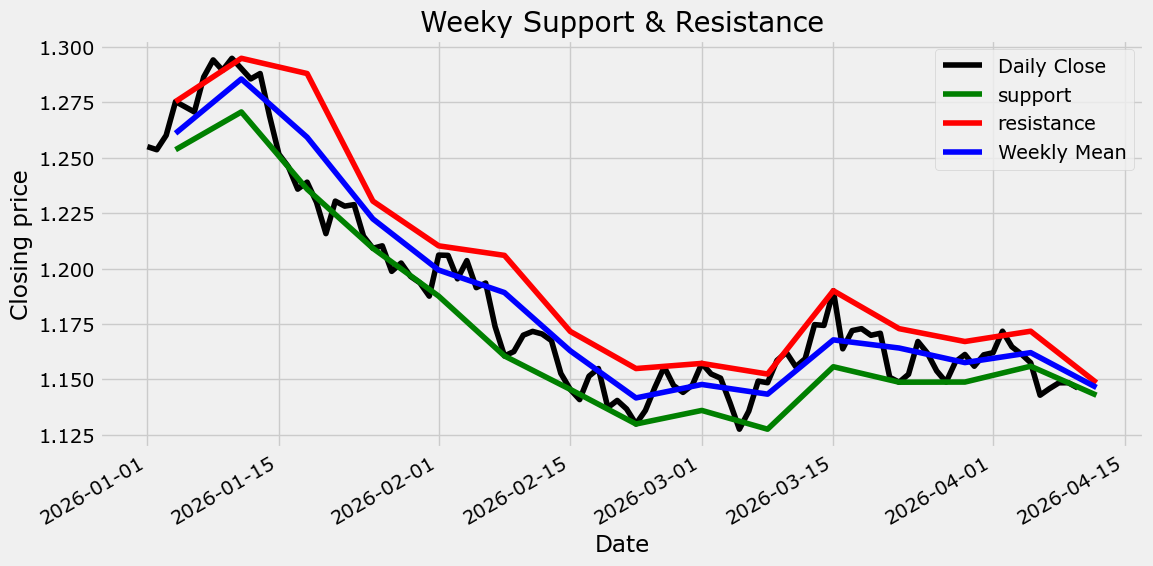

In [26]:
# My Attempt

x = df.resample('W').min()
y = df.resample('W').max()
z = df.resample('W').mean()

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.figure(figsize=(12, 6)) 

plt.plot(df.index,df['Close'],color='black',
         label='Daily Close')
plt.plot(x.index,x['Close'],color='green',
         label='support')
plt.plot(y.index,y['Close'],color='red',
         label='resistance')
plt.plot(z.index,z['Close'],color='blue',
         label='Weekly Mean')

plt.gcf().autofmt_xdate()

plt.title('Weeky Support & Resistance')
plt.xlabel('Date')
plt.ylabel('Closing price')
plt.legend()

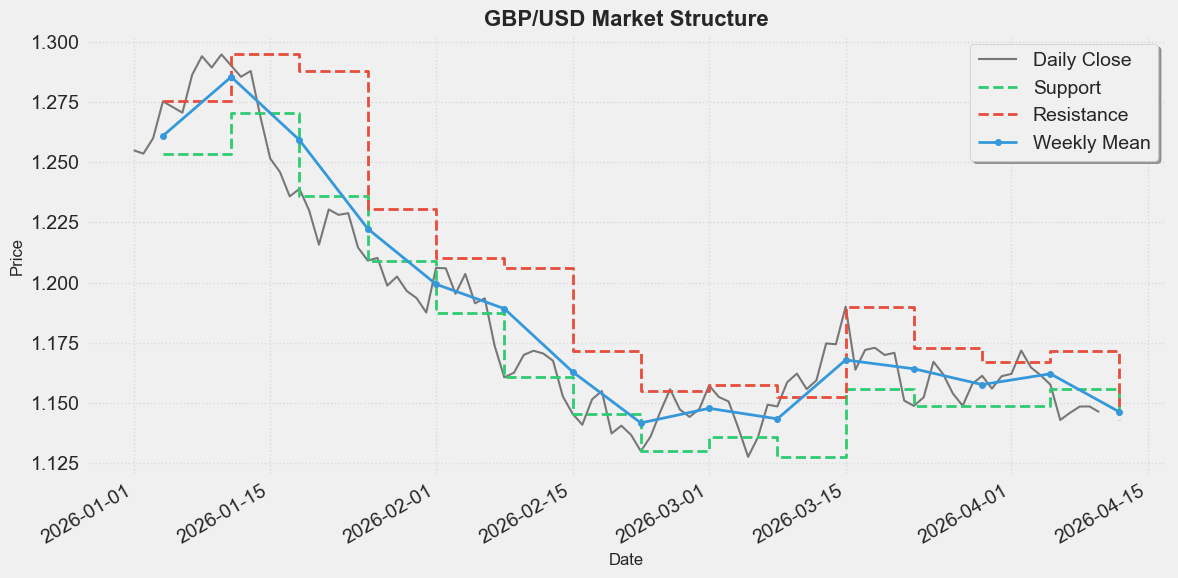

In [31]:
# Copied Attempt 

import matplotlib.pyplot as plt

# Set the style
plt.style.use('fivethirtyeight')
plt.figure(figsize=(12, 6)) 

# 1. Daily Close - Thinner and slightly faded
plt.plot(df.index, df['Close'], color='black', linewidth=1.5, alpha=0.5, label='Daily Close')

# 2. Support - Steps + Dashed
plt.plot(x.index, x['Close'], color='#2ecc71', linewidth=2, 
         drawstyle='steps-post', linestyle='--', label='Support')

# 3. Resistance - Steps + Dashed
plt.plot(y.index, y['Close'], color='#e74c3c', linewidth=2, 
         drawstyle='steps-post', linestyle='--', label='Resistance')

# 4. The Mean (Optional but makes it 'Fine')
plt.plot(z.index, z['Close'], color='#3498db', linewidth=2, marker='o', markersize=4, label='Weekly Mean')

# Formatting
plt.gcf().autofmt_xdate()
plt.title('GBP/USD Market Structure', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', frameon=True, shadow=True)

plt.tight_layout()
plt.show()


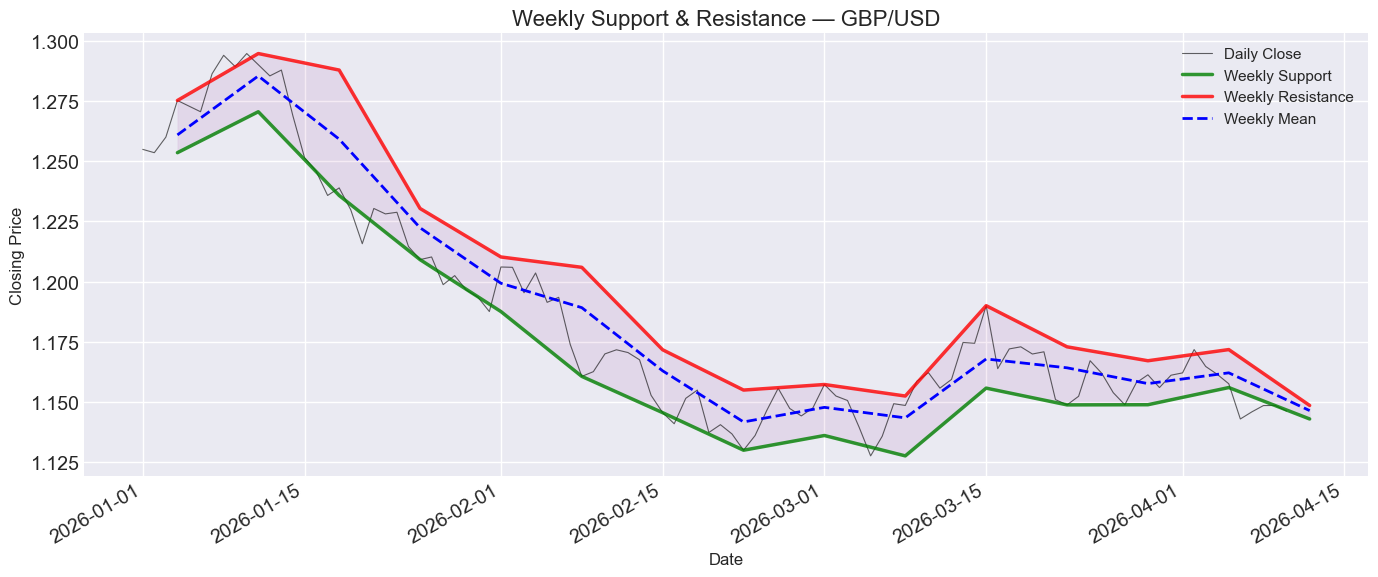

In [32]:
# Copied Attempt 2

x = df.resample('W').min()
y = df.resample('W').max()
z = df.resample('W').mean()

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')  # cleaner than fivethirtyeight
plt.figure(figsize=(14, 6))

# Daily close thin so it doesn't overpower
plt.plot(df.index, df['Close'], color='black', 
         label='Daily Close', linewidth=0.8, alpha=0.6)

# Support and resistance thicker and slightly transparent
plt.plot(x.index, x['Close'], color='green', 
         label='Weekly Support', linewidth=2.5, alpha=0.8)
plt.plot(y.index, y['Close'], color='red', 
         label='Weekly Resistance', linewidth=2.5, alpha=0.8)

# Mean as dashed line so it's distinct
plt.plot(z.index, z['Close'], color='blue', 
         label='Weekly Mean', linewidth=2, linestyle='--')

# Shade zone between support and resistance
plt.fill_between(x.index, x['Close'], y['Close'], 
                 alpha=0.08, color='purple')

plt.gcf().autofmt_xdate()
plt.title('Weekly Support & Resistance — GBP/USD', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


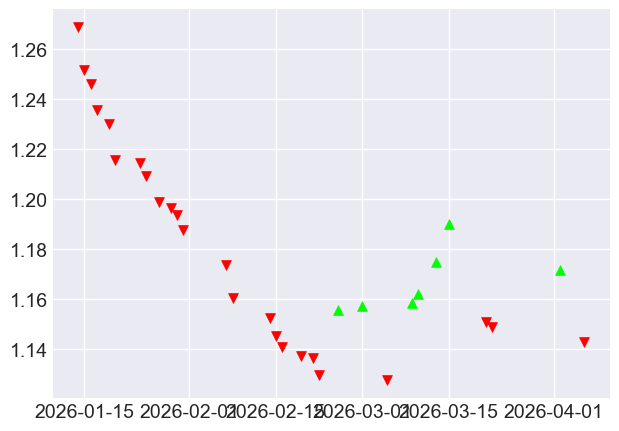

In [33]:
# Detect BOS points
highs = df['Close'].rolling(10).max()
lows = df['Close'].rolling(10).min()

bos_bull = df['Close'] > highs.shift(1)  # broke above previous high
bos_bear = df['Close'] < lows.shift(1)   # broke below previous low

# Plot them as scatter points on the chart
plt.scatter(df.index[bos_bull], df['Close'][bos_bull], 
            color='lime', marker='^', s=50, label='Bullish BOS')
plt.scatter(df.index[bos_bear], df['Close'][bos_bear], 
            color='red', marker='v', s=50, label='Bearish BOS')


# or

In [2]:
import pandas as pd
import io

# io lets us treat a text string like a real CSV file
# so we don't need to actually load a file from disk
data = """Date,Close
2023-01-02,1.2095
2023-01-03,1.1965
2023-01-04,1.2050
2023-01-05,1.2100
2023-01-06,1.2200"""

# Read the string as if it were a CSV file
df = pd.read_csv(io.StringIO(data))

# Convert the Date column to proper datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as the index so it behaves like a time series
df.set_index('Date', inplace=True)

# pct_change() calculates: (today - yesterday) / yesterday
# This gives the daily % return as a decimal (0.02 = 2%)
# First row is always NaN because there's no "yesterday" to compare
df['Daily Return'] = df['Close'].pct_change()

# std() of the daily returns = how much returns vary day to day
# This IS volatility in finance — you got this already!
volatility = df['Daily Return'].std()

print(df)
print(f"\nAverage Volatility: {volatility:.4f}")


             Close  Daily Return
Date                            
2023-01-02  1.2095           NaN
2023-01-03  1.1965     -0.010748
2023-01-04  1.2050      0.007104
2023-01-05  1.2100      0.004149
2023-01-06  1.2200      0.008264

Average Volatility: 0.0088
